<a href="https://colab.research.google.com/github/bijoy-420/python-course-project/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import all necessary model

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler



# Load Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart.csv')

# **Explore Dataset and Preprocessing**

In [10]:
df.shape

(1025, 14)

In [11]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
sex,302.0,0.682119,0.466426,0.0,0.00,1.0,1.00,1.0
cp,302.0,0.963576,1.032044,0.0,0.00,1.0,2.00,3.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
fbs,302.0,0.149007,0.356686,0.0,0.00,0.0,0.00,1.0
restecg,302.0,0.526490,0.526027,0.0,0.00,1.0,1.00,2.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
exang,302.0,0.327815,0.470196,0.0,0.00,0.0,1.00,1.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


target
1    164
0    138
Name: count, dtype: int64


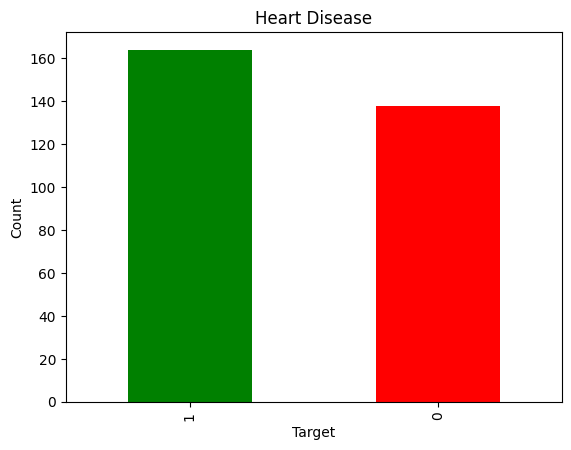

In [20]:
print(df['target'].value_counts())
#plot
df['target'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Heart Disease')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

# Train_test_split Dataset

In [23]:
X=df.drop('target',axis=1)
y=df['target']
print(f'features (X):')
print(f'shape:{X.shape}')
print(f'Colmuns:{X.columns.tolist()}')

print(f'\n Target (y):')
print(f'shape:{y.shape}')
print(f'values:0 (Healthy) and 1 (Disease)')



features (X):
shape:(302, 13)
Colmuns:['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

 Target (y):
shape:(302,)
values:0 (Healthy) and 1 (Disease)


In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
print(f"shape of X_train:{X_train.shape}")
print(f"shape of X_test:{X_test.shape}")

shape of X_train:(241, 13)
shape of X_test:(61, 13)


# Standarization for KNN

In [28]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(f'features scaling is complete')

features scaling is complete


# Model 1:K_Nearest Neighbors(KNN)

Best k:11


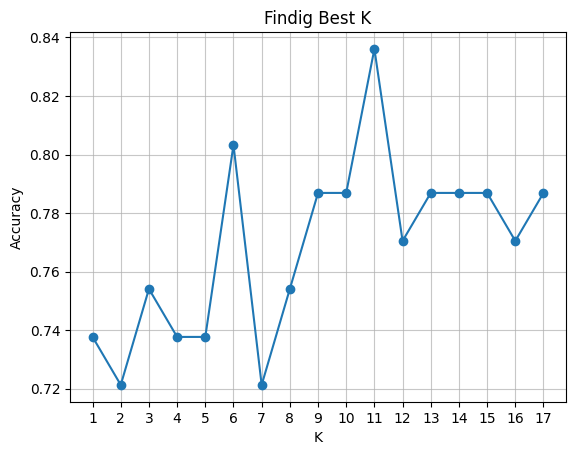

In [34]:
accuracis=[]
for k in range(1,18):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train_scaled,y_train)
  accuracis.append(accuracy_score(y_test,knn.predict(X_test_scaled)))
best_k=accuracis.index(max(accuracis))+1
print(f"Best k:{best_k}")

plt.plot(range(1,18),accuracis,marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Findig Best K")
plt.xticks(range(1,18))
plt.grid(alpha=0.7)
plt.show()



In [36]:
knn_model=KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled,y_train)
predictions=knn_model.predict(X_test_scaled)
accuracy=accuracy_score(y_test,predictions)
print(f"Accuracy:{accuracy}")


Accuracy:0.8360655737704918


# Classification Matrix

In [39]:
print(classification_report(y_test,predictions,target_names=['Healthy','Disease']))

              precision    recall  f1-score   support

     Healthy       0.92      0.75      0.83        32
     Disease       0.77      0.93      0.84        29

    accuracy                           0.84        61
   macro avg       0.85      0.84      0.84        61
weighted avg       0.85      0.84      0.84        61



# **Confusion matrix**

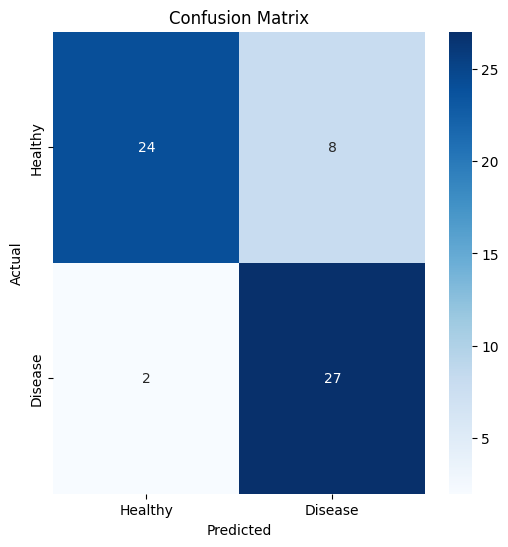

In [40]:
cm_knn=confusion_matrix(y_test,predictions)
plt.figure(figsize=(6,6))
sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues',xticklabels=['Healthy','Disease'],yticklabels=['Healthy','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Model 2:Decision Tree**

In [43]:
dt_model=DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train,y_train)
prediction=dt_model.predict(X_test)
dt_accuracy=accuracy_score(y_test,prediction)
print(f'accuracy_score:{dt_accuracy}')

accuracy_score:0.7540983606557377


# classification report for DT

In [44]:
print(classification_report(y_test,prediction,target_names=['Healthy','Disease']))

              precision    recall  f1-score   support

     Healthy       0.74      0.81      0.78        32
     Disease       0.77      0.69      0.73        29

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



# Confusion matrix for DT

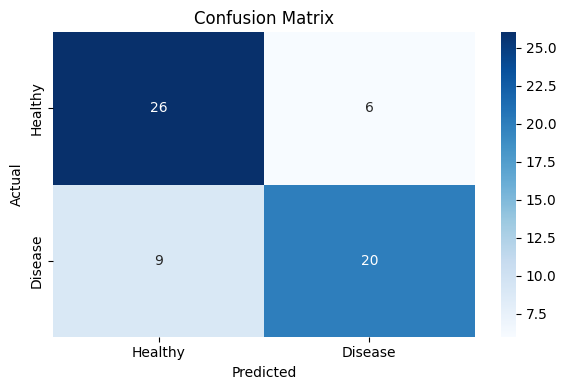

In [48]:
cm_dt=confusion_matrix(y_test,prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Blues',xticklabels=['Healthy','Disease'],yticklabels=['Healthy','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Find importance features

 Feature  Importance
      cp    0.444340
 oldpeak    0.219580
    chol    0.097139
      ca    0.082132
     age    0.054565
    thal    0.052507
     sex    0.037060
 thalach    0.007515
trestbps    0.005162
   exang    0.000000
 restecg    0.000000
     fbs    0.000000
   slope    0.000000


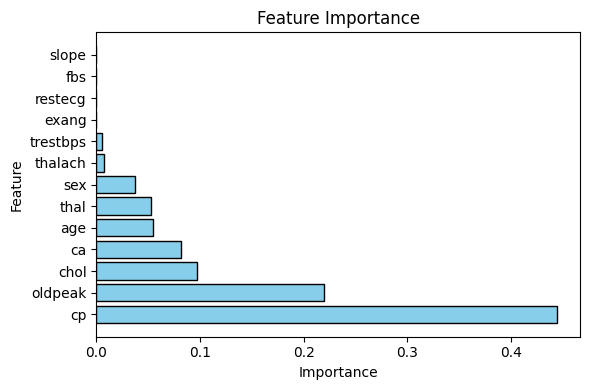

In [52]:
feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':dt_model.feature_importances_}).sort_values('Importance',ascending=False)

print(feature_importance.to_string(index=False))

plt.figure(figsize=(6,4))
plt.barh(feature_importance['Feature'],feature_importance['Importance'],
      color='skyblue',edgecolor='black'   )
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


# Model 3:RandomForest

In [53]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train,y_train)
prediction1=rf_model.predict(X_test)
rf_accuracy=accuracy_score(y_test,prediction1)
print(f'accuracy_score:{rf_accuracy}')

accuracy_score:0.8524590163934426


# classification report for RF

In [56]:
print(classification_report(y_test,prediction1,target_names=['Healthy','Disease']))

              precision    recall  f1-score   support

     Healthy       0.93      0.78      0.85        32
     Disease       0.79      0.93      0.86        29

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



# confusion matrix for RF

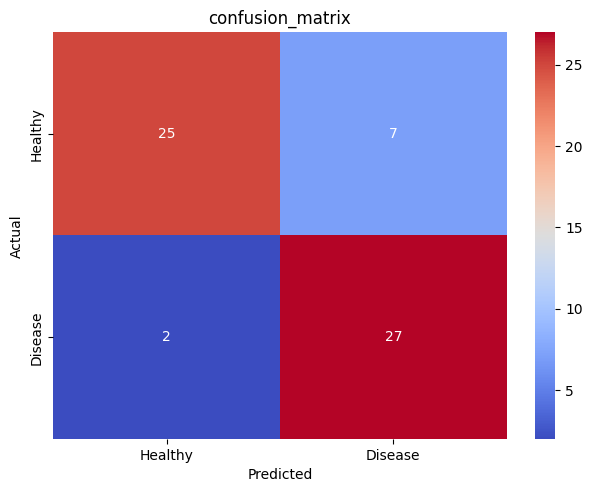

In [58]:
cm1=confusion_matrix(y_test,prediction1)
sns.heatmap(cm1,annot=True,fmt='d',cmap='coolwarm',xticklabels=['Healthy','Disease'],yticklabels=['Healthy','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.title('confusion_matrix')
plt.show()

# find importance features

 Feature  Importance
      cp    0.197253
    thal    0.146988
 thalach    0.126786
      ca    0.119137
 oldpeak    0.112810
   exang    0.078959
   slope    0.058146
     sex    0.050422
     age    0.044502
    chol    0.028282
trestbps    0.018948
 restecg    0.017457
     fbs    0.000311


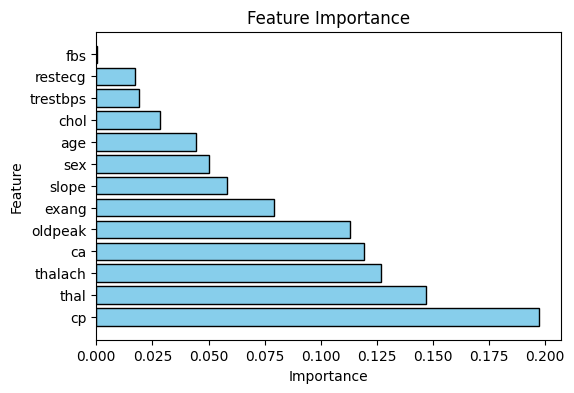

In [61]:
rf_feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
}).sort_values('Importance',ascending=False)
print(rf_feature_importance.to_string(index=False))
plt.figure(figsize=(6,4))
plt.barh(rf_feature_importance['Feature'],rf_feature_importance['Importance'],color='skyblue',edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Performance Comparison

In [63]:
comparison=pd.DataFrame({
    'Model':['KNN','Decision Tree','Random Forest'],
    'Accuracy':[accuracy,dt_accuracy,rf_accuracy],
    'Accuracy %':[f"{accuracy*100:.2f}%",f"{dt_accuracy*100:.2f}%",f"{rf_accuracy*100:.2f}%"]
})
comparison=comparison.sort_values('Accuracy',ascending=False)
print("\n"+comparison.to_string(index=False))
best_model=comparison.iloc[0]['Model']
best_acc=comparison.iloc[0]['Accuracy']
print(f"\nBest Model:{best_model}")
print(f"Accuracy :{best_acc:.4f} ({best_acc*100:.2f}%)")


        Model  Accuracy Accuracy %
Random Forest  0.852459     85.25%
          KNN  0.836066     83.61%
Decision Tree  0.754098     75.41%

Best Model:Random Forest
Accuracy :0.8525 (85.25%)


# Visualization of comparision

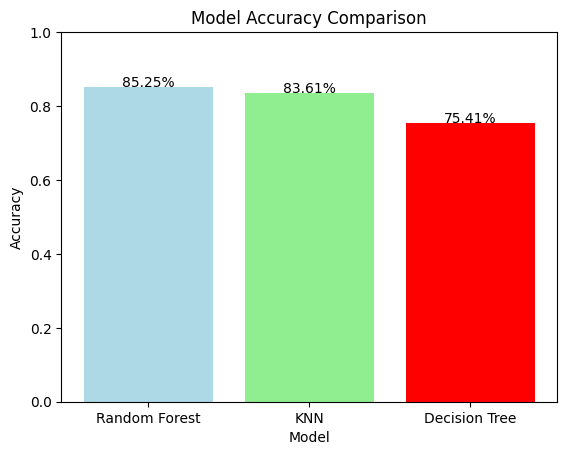

In [66]:
plt.bar(comparison['Model'],comparison['Accuracy'],color=['lightblue','lightgreen','red','coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0,1])

for i,acc in enumerate(comparison['Accuracy']):
  plt.text(i,acc,f'{acc*100:.2f}%',ha='center')